# Dataset Statistics

For use in Figure 3.

Table of Contents:
1. Imports and load data
2. Subject statistics summary
3. Test-path statistics summary
4. Plot subject and path accuracy CDFs (Fig. 3A-B)
5. Directional path accuracy differences (Fig. 3C)
6. Effect of start vs. end node on accuracy (Fig. 3D)
7. Heatmaps and foils (Fig. 3E)
8. Miscellaneous Archives

## 1. Imports and load data

In [340]:
import matplotlib.pyplot as plt
import numpy as np  
import pandas as pd 
import plotly.graph_objs as go
import seaborn as sns
import warnings


from plotly.offline import plot
from plotly.subplots import make_subplots

from scipy import stats

from flow_tree_utils import generate_trajs_from_df, load_test_df, OBJECTS

warnings.filterwarnings("ignore")
pd.options.mode.chained_assignment = None

# Load data into dataframe
test_df = load_test_df(include_subject_info=True)

# Flow Trees and regression

For use in Figures 4 and 5.

Table of Contents:
1. Imports and load data
2. Plot some path Flow Tree examples (Fig. 4B)
4. Plot all path Flow Trees (Fig. 5)
5. Regression (Fig. 5)
6. Backbone thickness
7. Miscellaneous Archives

## 2. Subject statistics summary 

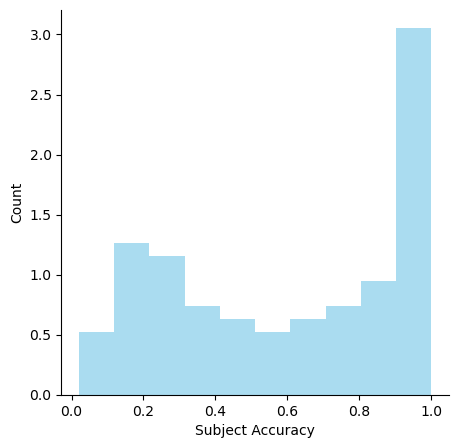


Summary Statistics of Subject Accuracies:
Min: 0.020833333333333332
Max: 1.0
Mean: 0.596434707903791
Std: 0.32084072655928697

Summary Statistics of Subject Path Attempt Counts:
Min: 48
Max: 48
Mean: 48.0
Std: 0.0


In [403]:
# Create a histogram to show probability distribution
plt.figure(figsize=(5,5))
plt.hist(test_df['subj_mean_acc'], bins=10, density=True, alpha=0.7, color='skyblue')

plt.grid(True, linestyle='--', alpha=0.7)
plt.xlabel('Subject Accuracy')
plt.ylabel('Count')
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.grid(False)

plt.show()

# Show summary statistics
print("\nSummary Statistics of Subject Accuracies:")
print(f"Min: {test_df['subj_mean_acc'].min()}")
print(f"Max: {test_df['subj_mean_acc'].max()}")
print(f"Mean: {test_df['subj_mean_acc'].mean()}")
print(f"Std: {test_df['subj_mean_acc'].std()}")

# Show summary statistics of counts
count_df = test_df.groupby("Subject").agg(
        # correct_count=("accuracy", lambda x: (x == 1).sum()),
        total_count=("accuracy", "count")
    ).reset_index()

print("\nSummary Statistics of Subject Path Attempt Counts:")
print(f"Min: {count_df['total_count'].min()}")
print(f"Max: {count_df['total_count'].max()}")
print(f"Mean: {count_df['total_count'].mean()}")
print(f"Std: {count_df['total_count'].std()}")

In [401]:
def make_distribution_plot(data, jitter_high=0.2, y_start=0.15, x_label="", x_ticks=np.arange(0, 1.1, 0.5)):
    fig, ax = plt.subplots(figsize=(8, 8))

    COLORS = ["#FF5A5F", "#FFB400", "#007A87"]

    # Half-violin plot as above
    # pt.half_violinplot(
    #     x=subj_mean_accs, #y="species", 
    #     palette=COLORS, 
    #     inner=None,  width=1, ax=ax
    # )
    sns.distplot(data, hist=False, kde=True, 
                bins=int(180/10), color = 'darkblue', 
                hist_kws={'edgecolor':'black'},
                kde_kws={'shade': False, 'linewidth': 8, 'clip': (0.0, 1.0)}, ax=ax)

    # Jitter the values on the vertical axis
    y = y_start + np.random.uniform(high=jitter_high, size=len(data))

    # Add the rain using the scatter method.
    ax.scatter(data, y, color=COLORS[0], alpha=0.6, s=100)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_visible(False)
    ax.spines["bottom"].set_linewidth(2.5)
    ax.yaxis.set_visible(False)

    ax.tick_params(axis='both', which='major', labelsize=30, width=2, length=10)
    plt.xticks(x_ticks)
    plt.xlabel(x_label, fontsize=30)
    plt.xlim(0,1)
    plt.show()

def run_tests_on_distribution(mean_accs):
    # Test if vary significantl
    # ie, does top quartile differ significantly from bottom quartile?

    # Top & bottom quartile
    q3 = np.percentile(mean_accs, 75)
    q1 = np.percentile(mean_accs, 25)

    top_quartile = mean_accs[mean_accs >= q3]
    bottom_quartile = mean_accs[mean_accs <= q1]

    print("Quartile means:")
    print(f"\tq1: {bottom_quartile.mean():.4f} q4: {top_quartile.mean():.4f}")
    t_stat, p_value = stats.ttest_ind(top_quartile, bottom_quartile)
    print(f"\tt={t_stat:.4f}, p={p_value:.4f}")

    # Top & bottom half
    h1 = np.percentile(mean_accs, 50)

    top_half = mean_accs[mean_accs >= h1]
    bottom_half = mean_accs[mean_accs < h1]

    print("Half means:")
    print(f"\th1: {top_half.mean():.4f} q2: {bottom_half.mean():.4f}")
    t_stat, p_value = stats.ttest_ind(top_half, bottom_half)
    print(f"\tt={t_stat:.4f}, p={p_value:.4f}")


    def cohen_d(x, y):
        """
        Calculates Cohen's d for two independent samples.
        x, y: numpy arrays or lists representing the two samples.
        """
        n1, n2 = len(x), len(y)
        s1, s2 = np.std(x, ddof=1), np.std(y, ddof=1) # ddof=1 for sample standard deviation
        
        pooled_std_dev = np.sqrt(((n1 - 1) * s1**2 + (n2 - 1) * s2**2) / (n1 + n2 - 2))
        
        d = (np.mean(x) - np.mean(y)) / pooled_std_dev
        return d

    print(f"Quartile d: {cohen_d(top_quartile, bottom_quartile)}")
    print(f"Half d: {cohen_d(top_half, bottom_half)}")

    print("Is this normal? p<0.05 means no")
    stat, p = stats.shapiro(mean_accs)
    print(stat, p)

    print("Kurtosis (normal=3)")
    kurt = stats.kurtosis(mean_accs, fisher=False)
    print(kurt)

In [402]:
# Test if vary significantly
subj_mean_accs = np.array(test_df.groupby(["Subject"])["subj_mean_acc"].mean().astype(float))
run_tests_on_distribution(subj_mean_accs)

Quartile means:
	q1: 0.1890 q4: 0.9576
	t=44.4070, p=0.0000
Half means:
	h1: 0.8831 q2: 0.3038
	t=20.4571, p=0.0000
Quartile d: 11.765508230076989
Half d: 4.154422038138555
Is this normal? p<0.05 means no
0.8934211665176428 9.679131407088405e-07
Kurtosis (normal=3)
1.5345955948719143


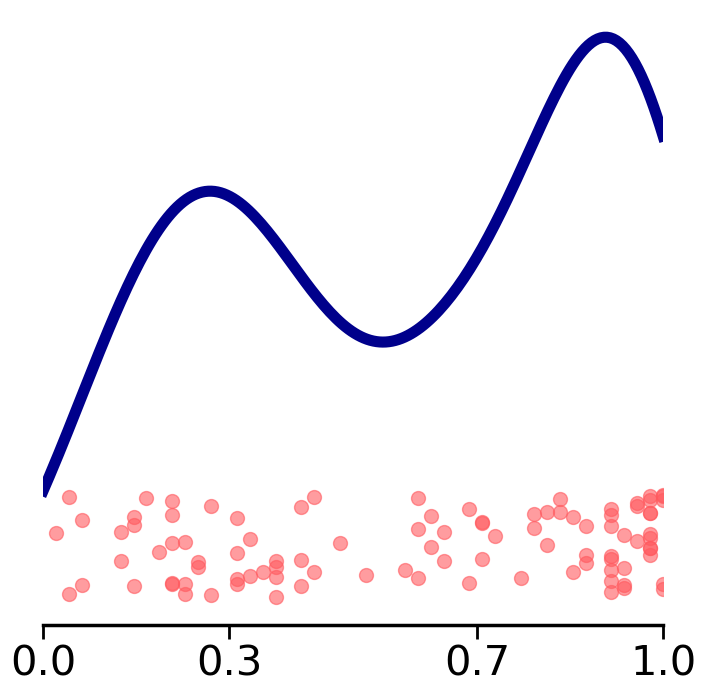

In [343]:
subj_mean_accs = test_df.groupby("Subject")["accuracy"].mean()
make_distribution_plot(subj_mean_accs, x_label="", x_ticks=[0, 0.3, 0.7, 1.0]) #Navigator Accuracy

### Gender statistics

In [344]:
male_test_df, female_test_df = test_df[test_df["is_man"]], test_df[~test_df["is_man"]]

print(f"Total count: {len(test_df.groupby('Subject'))}")
print(f"Count male: {len(male_test_df.groupby('Subject'))}")
print(f"Count female: {len(female_test_df.groupby('Subject'))}")

print("\nSummary Statistics of Subject Ages:")
ages = test_df.groupby("Subject")["age"].transform("mean")
ages.describe()

Total count: 97
Count male: 51
Count female: 46

Summary Statistics of Subject Ages:


count    4656.000000
mean       20.577320
std         2.666745
min        18.000000
25%        19.000000
50%        20.000000
75%        21.000000
max        31.000000
Name: age, dtype: float64

In [345]:
male_accs = male_test_df.groupby(["Subject"])["accuracy"].transform("mean")
print("MALE:")
print(f"Min: {male_accs.min()}")
print(f"Max: {male_accs.max()}")
print(f"Mean: {male_accs.mean()}")
print(f"Std: {male_accs.std()}")

female_accs = female_test_df.groupby(["Subject"])["accuracy"].transform("mean")
print("FEMALE:")
print(f"Min: {female_accs.min()}")
print(f"Max: {female_accs.max()}")
print(f"Mean: {female_accs.mean()}")
print(f"Std: {female_accs.std()}")

print(stats.ttest_ind(male_accs, female_accs))


MALE:
Min: 0.0625
Max: 1.0
Mean: 0.7438725490196079
Std: 0.29135520911972573
FEMALE:
Min: 0.020833333333333332
Max: 0.9375
Mean: 0.4329710144927536
Std: 0.2686170735841808
TtestResult(statistic=37.7243117762809, pvalue=5.616770675177833e-272, df=4654.0)


## 3. Test-path statistics summary

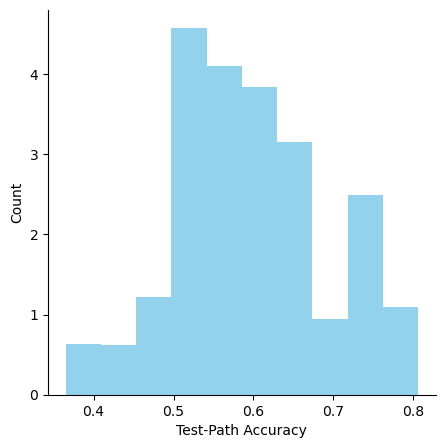


Summary Statistics of Start-End Path Accuracies:
Min: 0.36507936507936506
Max: 0.8061224489795918
Mean: 0.5964347079037882
Std: 0.09552900486846679

Summary Statistics of Start-End Path Attempt Counts:
Min: 34
Max: 98
Mean: 64.66666666666667
Std: 5.828535921302661


In [346]:
# Create a histogram to show probability distribution
plt.figure(figsize=(5,5))
plt.hist(test_df["path_mean_acc"], bins=10, density=True, alpha=0.9, color='skyblue')

plt.grid(True, linestyle='--', alpha=0.7)
plt.xlabel('Test-Path Accuracy')
plt.ylabel('Count')
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.grid(False)

plt.show()

# Show summary statistics
print("\nSummary Statistics of Start-End Path Accuracies:")
print(f"Min: {test_df['path_mean_acc'].min()}")
print(f"Max: {test_df['path_mean_acc'].max()}")
print(f"Mean: {test_df['path_mean_acc'].mean()}")
print(f"Std: {test_df['path_mean_acc'].std()}")

# Show summary statistics of counts
count_df = test_df.groupby("StartEnd").agg(
        correct_count=("accuracy", lambda x: (x == 1).sum()),
        total_count=("accuracy", "count")
    ).reset_index()

print("\nSummary Statistics of Start-End Path Attempt Counts:")
print(f"Min: {count_df['total_count'].min()}")
print(f"Max: {count_df['total_count'].max()}")
print(f"Mean: {count_df['total_count'].mean()}")
print(f"Std: {count_df['total_count'].std()}")

In [404]:
# Test if vary significantly
mean_accs = np.array(test_df.groupby(["StartEnd"])["path_mean_acc"].mean().astype(float))
run_tests_on_distribution(mean_accs)

Quartile means:
	q1: 0.4842 q4: 0.7231
	t=15.3327, p=0.0000
Half means:
	h1: 0.6695 q2: 0.5196
	t=10.9328, p=0.0000
Quartile d: 5.1108955105765155
Half d: 2.5768761682131442
Is this normal? p<0.05 means no
0.9806565354866508 0.33363209160771556
Kurtosis (normal=3)
2.7026800704522485


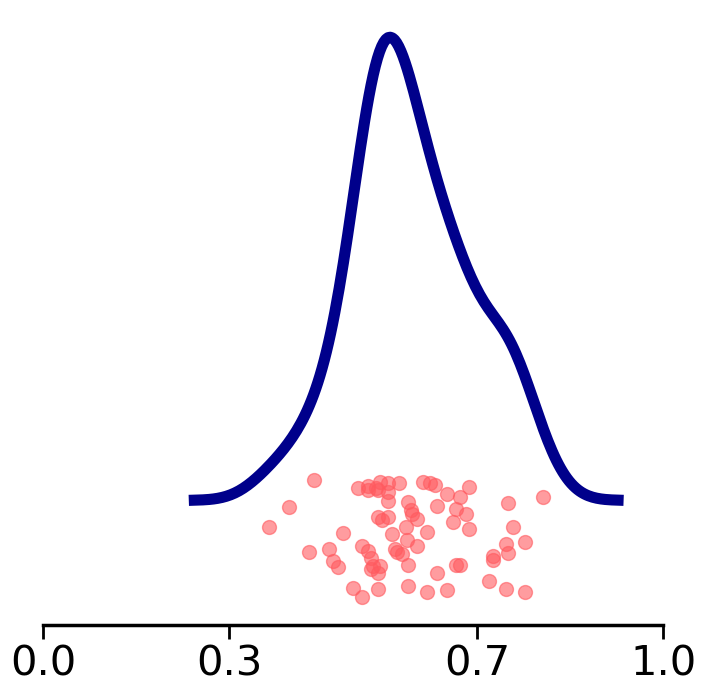

In [347]:
path_mean_accs = test_df.groupby(["StartAt", "EndAt"])["accuracy"].mean()
make_distribution_plot(path_mean_accs, jitter_high=1.1, y_start=-0.9, x_label="", x_ticks=[0, 0.3, 0.7, 1.0]) # "Path Accuracy"

## 4. Plot subject and path accuracy CDFs (Fig. 3A-B)

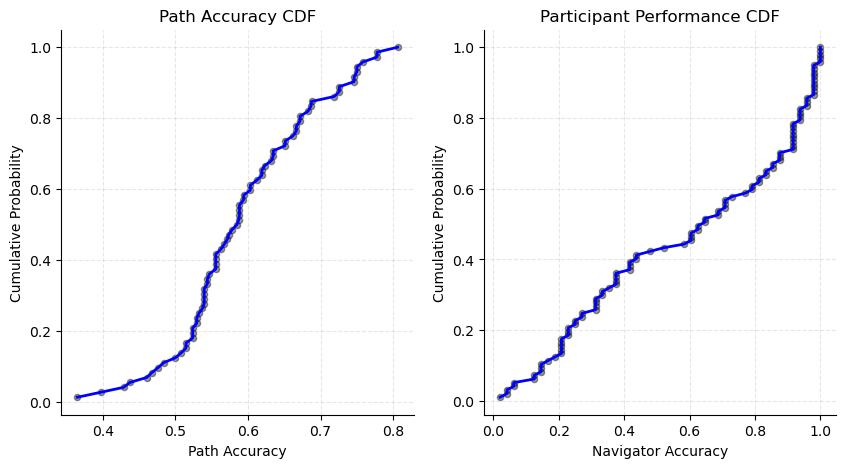

In [348]:
# Create a figure with three subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))

# 1. CDF of path accuracies
path_data = test_df.groupby("StartEnd")["accuracy"].apply(np.mean)
sorted_data = np.sort(path_data.values)
cumulative_prob = np.arange(1, len(sorted_data) + 1) / len(sorted_data)

ax1.plot(sorted_data, cumulative_prob, 'b-', linewidth=2)
ax1.scatter(sorted_data, cumulative_prob, alpha=0.4, color='black', s=20)
ax1.set_xlabel('Path Accuracy')
ax1.set_ylabel('Cumulative Probability')
ax1.set_title('Path Accuracy CDF')
ax1.grid(True, linestyle='--', alpha=0.3)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

# 2. CDF of navigator accuracies
subject_data = test_df.groupby("Subject")["accuracy"].apply(np.mean)
sorted_data = np.sort(subject_data.values)
cumulative_prob = np.arange(1, len(sorted_data) + 1) / len(sorted_data)

ax2.plot(sorted_data, cumulative_prob, 'b-', linewidth=2)
ax2.scatter(sorted_data, cumulative_prob, alpha=0.4, color='black', s=20)
ax2.set_xlabel('Navigator Accuracy')
ax2.set_ylabel('Cumulative Probability')
ax2.set_title('Participant Performance CDF')
ax2.grid(True, linestyle='--', alpha=0.3)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

## 5. Directional path accuracy differences (Fig. 3C)

In [378]:
# Plot accuracy differences!
acc_differences = {}
allacc1 = []
allacc2 = []
accs = {}
rev_accs = {}
p_valuesd = {}
obj_pairs = []
p_values = []
for i in range(len(OBJECTS)):
    for j in range(i+1, len(OBJECTS)):
        start_node, end_node = OBJECTS[i], OBJECTS[j]
        
        accs1 = test_df[(test_df["StartAt"]==start_node) & (test_df["EndAt"]==end_node)]["accuracy"]
        accs2 = test_df[(test_df["StartAt"]==end_node) & (test_df["EndAt"]==start_node)]["accuracy"]

        # Perform Mann-Whitney U test since we can't assume normal distribution
        statistic, p_value = stats.mannwhitneyu(accs1, accs2, alternative='two-sided')

        if p_value < 0.01: print(start_node, end_node, statistic, p_value)
        
        acc1 = np.mean(accs1)
        acc2 = np.mean(accs2)
        if p_value < 0.01: print(acc1, acc2)

        allacc1.append(acc1)
        allacc2.append(acc2)

        better_path = (start_node, end_node) if acc1 > acc2 else (end_node, start_node)
        
        accs[better_path] = max(acc1, acc2)
        rev_accs[better_path] = min(acc1, acc2)
        
        acc_differences[better_path] = np.abs(acc1 - acc2)
        p_valuesd[better_path] = p_value
        p_values.append(p_value)
        obj_pairs.append(OBJECTS[i]+OBJECTS[j])

# Apply Benjamini-Hochberg correction for false positives
# Bonferroni is another possiblity, but allegedly too stringent
bh_p_values = stats.false_discovery_control(p_values, method="bh")

print(p_values)
print(bh_p_values)
# Count how many significant differences we have after correction
print(f"Number of significant differences after Bonferroni correction (p < {.05/36:.5f}): {sum(p < .05/36 for p in p_values)}")
print(f"Number of significant differences after Benjamini-Hochberg correction: {sum(p < .05 for p in bh_p_values)}")

# Convert acc_differences dict to lists for plotting and sort by difference
sorted_items = sorted(acc_differences.items(), key=lambda x: x[1], reverse=True)
x_vals = []
y_vals = []
y1_vals = []
y2_vals = []
p_vals = []
hover_text = []
for (start, end), diff in sorted_items:
    x_vals.append(f"{start}_{end}")
    y_vals.append(diff)
    y1_vals.append(accs[(start, end)])
    y2_vals.append(rev_accs[(start, end)])
    p_vals.append(p_valuesd[(start, end)])
    hover_text.append(f"Start: {start}<br>End: {end}<br>Acc Diff: {diff:.3f}<br>p-value: {p_valuesd[(start, end)]:.3f}")

# Create marker colors based on significance
marker_colors = ['red' if p < 0.01 else 'gray' for p in p_vals]

# Create plotly scatter plot
fig = go.Figure(data=[
    go.Scatter(
        x=x_vals,
        y=y_vals,
        name='Difference',
        mode='markers+text',
        marker=dict(
            size=12,
            color=marker_colors
        ),
        hovertext=hover_text,
        hoverinfo='text'
    ),
])

fig.update_layout(
    title="Absolute Accuracy Differences Between Path Directions<br><sub>Red points indicate statistically significant differences (p < 0.05)</sub>",
    xaxis_title="Start_End Pair", 
    yaxis_title="Directional accuracy difference",
    height=350,
    width=700,
    showlegend=False,
    plot_bgcolor='white',
    paper_bgcolor='white'
)

fig.show()

O A 1522.0 0.005656390221192314
0.4375 0.6825396825396826
N P 1543.5 0.008482302216961972
0.5555555555555556 0.7777777777777778
W P 1473.5 0.004046103925279947
0.532258064516129 0.7777777777777778
[0.06922650963808596, 0.6924230283273852, 0.06494745265550673, 0.15439614569923318, 0.12569260507932234, 0.19824392880027486, 0.005656390221192314, 0.03137676583649947, 0.040911704118939934, 0.8610781483921253, 0.4326965947449736, 0.6056132153265957, 0.7777027491706386, 0.6427516248014062, 0.2832789233382169, 0.05687319019725352, 0.01619026716905169, 0.2581553679912155, 0.0306379898923156, 0.10150550280704534, 0.008482302216961972, 0.47271018764674033, 0.32357736845803997, 0.7814246851413158, 0.7973617641892098, 0.14970925584157044, 0.07964132284067149, 0.6484916649773915, 0.8384719901745138, 0.032823322029494596, 0.326992631686817, 0.09077282632494646, 0.004046103925279947, 0.2381318171629554, 0.5017879642078112, 0.41617265567054706]
[0.22655949 0.80410416 0.22655949 0.32695654 0.30166225 0.

In [371]:
# Compare accuracy differences in general.
# I don't think one-way anova works.
# Instead we need to group into higher accuracy and lower accuracy for each pair.
# Then just do a t-test??

better_direction_accs = []
worse_direction_accs = []
for i in range(len(OBJECTS)):
    for j in range(i+1, len(OBJECTS)):
        start_node, end_node = OBJECTS[i], OBJECTS[j]
    
        accs1 = test_df[(test_df["StartAt"]==start_node) & (test_df["EndAt"]==end_node)]["accuracy"]
        accs2 = test_df[(test_df["StartAt"]==end_node) & (test_df["EndAt"]==start_node)]["accuracy"]

        acc1 = np.mean(accs1)
        acc2 = np.mean(accs2)

        if acc1 > acc2:
            better_direction_accs.extend(accs1)
            worse_direction_accs.extend(accs2)
        else:
            better_direction_accs.extend(accs1)
            worse_direction_accs.extend(accs2)

# Perform Mann-Whitney U test since we can't assume normal distribution
statistic, p_value = stats.mannwhitneyu(better_direction_accs, worse_direction_accs, alternative="less")

print(np.mean(better_direction_accs))
print(np.mean(worse_direction_accs))
print(f"{statistic} p={p_value}")

0.5630178805058875
0.6288616165890817
2530797.0 p=2.349596092160965e-06


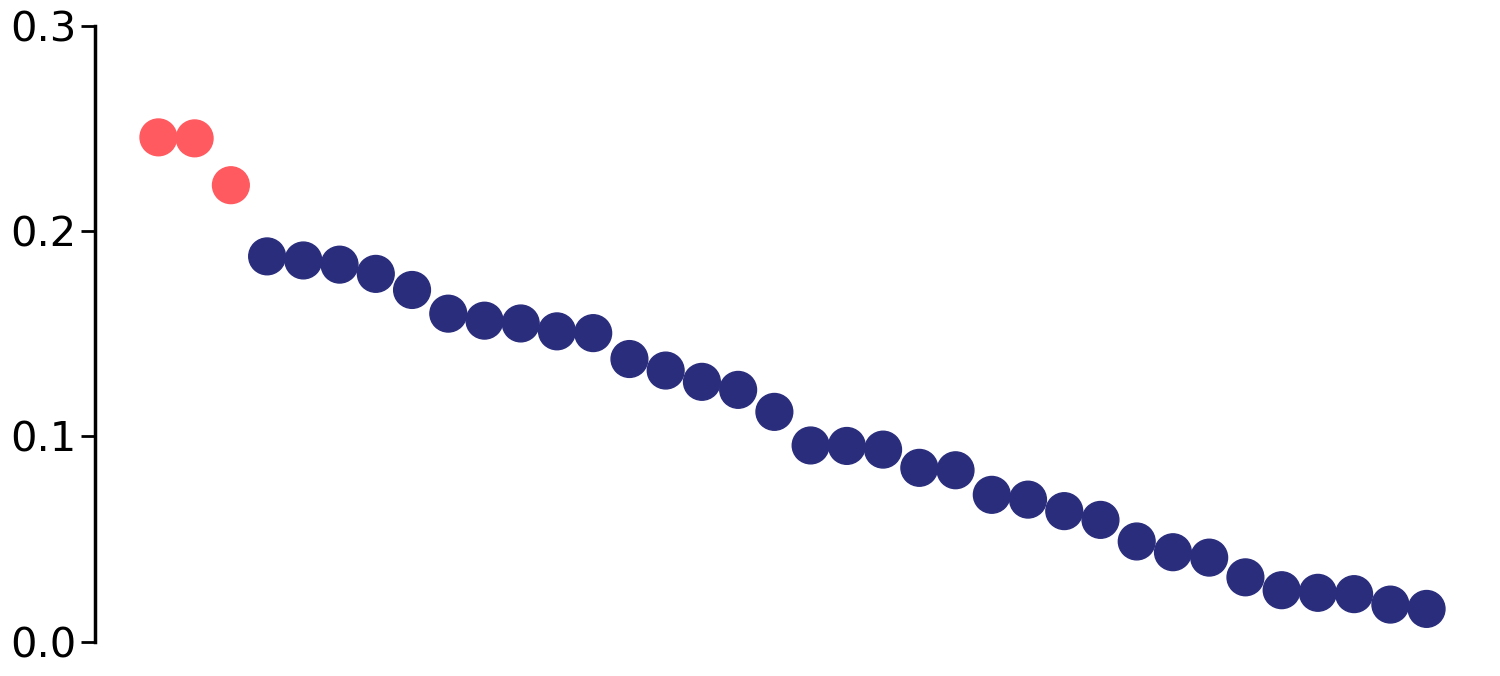

In [350]:
fig, ax = plt.subplots(figsize=(18, 8))

# Create marker colors based on significance
marker_colors = ["#FF5A5F" if p < 0.01 else "#2a2d7c" for p in p_vals]

ax.scatter(x_vals, y_vals, color=marker_colors, alpha=1, s=700)


ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_linewidth(2.5)
ax.spines["bottom"].set_visible(False)
ax.xaxis.set_visible(False)

ax.tick_params(axis='both', which='major', labelsize=30, width=2, length=10)
plt.yticks([0.0, 0.1, 0.2, 0.3])

plt.show()

## 6. Effect of start vs. end node on accuracy (Fig. 3D)

### Plotting

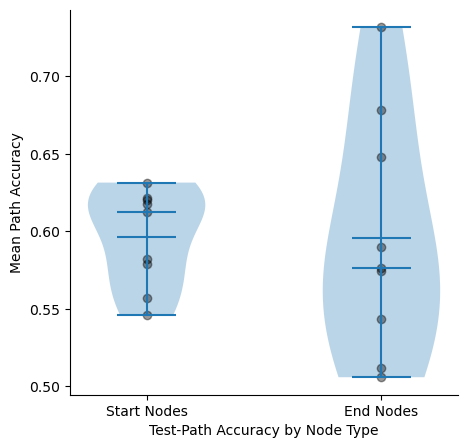


Summary Statistics of Path Accuracies by Start Node:
count    9.000000
mean     0.596434
std      0.031072
min      0.546154
25%      0.579256
50%      0.612717
75%      0.619962
max      0.631478
Name: accuracy, dtype: float64

Summary Statistics of Path Accuracies by End Node:
count    9.000000
mean     0.595482
std      0.076487
min      0.505859
25%      0.543353
50%      0.576402
75%      0.647860
max      0.731752
Name: accuracy, dtype: float64


In [351]:
# First simple plot
path_accuracies_by_start = test_df.groupby(["StartAt"])["accuracy"].mean().reset_index()
path_accuracies_by_end = test_df.groupby(["EndAt"])["accuracy"].mean().reset_index()

# Create a violin plot to show probability distribution
plt.figure(figsize=(5,5))
plt.violinplot([path_accuracies_by_start["accuracy"], path_accuracies_by_end["accuracy"]], showmeans=True, showmedians=True)

# Add scatter points
plt.scatter(np.ones(len(path_accuracies_by_start["accuracy"])), path_accuracies_by_start["accuracy"], alpha=0.4, color="black")
plt.scatter(2 * np.ones(len(path_accuracies_by_end["accuracy"])), path_accuracies_by_end["accuracy"], alpha=0.4, color="black")

plt.xticks([1, 2], ['Start Nodes', 'End Nodes'])

plt.grid(True, linestyle='--', alpha=0.7)
plt.xlabel('Test-Path Accuracy by Node Type')
plt.ylabel('Mean Path Accuracy')
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.grid(False)

plt.show()

# Show summary statistics
print("\nSummary Statistics of Path Accuracies by Start Node:")
print(path_accuracies_by_start['accuracy'].describe())

print("\nSummary Statistics of Path Accuracies by End Node:")
print(path_accuracies_by_end['accuracy'].describe())


      start_node_means  numbers
2             0.579256        2
3             0.621359        7
4             0.631478        8
5             0.612717        4
6             0.617934        5
...                ...      ...
5082          0.556840        1
5083          0.546154        0
5084          0.582205        3
5085          0.546154        0
5086          0.612717        4

[4656 rows x 2 columns]
StartAt  EndAt
A        I        0.555556
         K        0.546875
         L        0.746269
         N        0.725806
         O        0.682540
                    ...   
Y        L        0.539683
         N        0.544118
         O        0.588235
         P        0.619048
         W        0.666667
Name: accuracy, Length: 72, dtype: float64 StartAt  EndAt
A        I        5.0
         K        5.0
         L        5.0
         N        5.0
         O        5.0
                 ... 
Y        L        1.0
         N        1.0
         O        1.0
         P        1.0
 

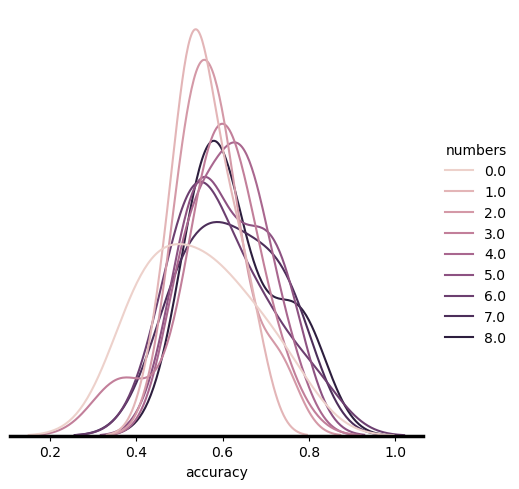

In [352]:

COLORS = ["#FF5A5F", "#FFB400", "#007A87"]

    
# # Create visualization of accuracies by start and end nodes
# fig, ax = plt.subplots(figsize=(8, 5))

# Calculate mean accuracy per start node to determine order
test_df["start_node_means"] = test_df.groupby('StartAt')['accuracy'].transform("mean")
order = "OYWNLAIKP"
dd = {order[i]: i for i in range(len(order))}
test_df["numbers"] = test_df["StartAt"].apply(lambda x: dd[x])


start_node_means = test_df.groupby(["StartAt", "EndAt"])['accuracy'].mean()
colors = test_df.groupby(["StartAt", "EndAt"])['numbers'].mean()

# bp = ax.boxplot(path_data)

print(test_df[["start_node_means", "numbers"]])
print(start_node_means, colors)
g = sns.displot(x=start_node_means, hue=colors, kind="kde", ax=ax)# hue="sex", col="species",)
            #   hist=False, kde=True, 
            #     bins=int(180/10), color = 'darkblue', 
            #     hist_kws={'edgecolor':'black'},
            #     kde_kws={'shade': False, 'linewidth': 8, 'clip': (0.0, 1.0)}, ax=ax)
ax = g.axes[0][0]

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)
ax.spines["bottom"].set_linewidth(2.5)
ax.yaxis.set_visible(False)

# ax.tick_params(axis='both', which='major', labelsize=30, width=2, length=10)
# plt.xticks([]])
# plt.xlabel(x_label, fontsize=30)


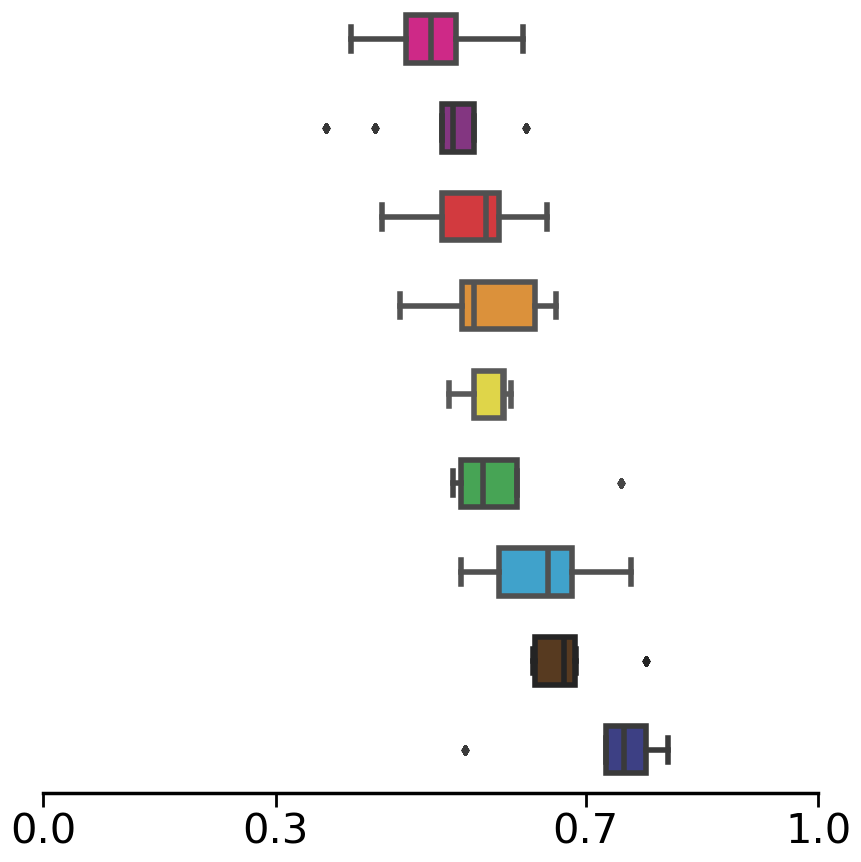

In [353]:

from matplotlib.gridspec import GridSpec

COLORS = ["#FF5A5F", "#FFB400", "#007A87"]


    
# Set up figure and grid
fig = plt.figure(figsize=(10, 10))  # Wider figure to accommodate 9 subplots
gs = GridSpec(9, 1, figure=fig, height_ratios=[2,2,2,2,2,2,2,2,2], hspace=.5)  # 1 row, 9 columns

# Mapping letters to indices for consistent order
order = "PYAIKLOWN"
dd = {order[i]: i for i in range(len(order))}
test_df["numbers"] = test_df["EndAt"].apply(lambda x: dd[x])

# Plotting one subplot per EndAt node

colors = ["#e90e8b", "#90298d", "#eb2127", "#f69320", "#f8eb30", "#38b34a", "#29abe2", "#603a17", "#313590"]

for i, node in enumerate(order):
    ax = fig.add_subplot(gs[i])
    df_from_this_start = test_df[test_df["EndAt"] == node]
    
    # sns.kdeplot(
    #     df_from_this_start["path_mean_acc"].astype(float),
    #     ax=ax,
    #     linewidth=4,
    #     fill=True,
    #     bw_adjust=2,
    #     color=colors[i]
    # )
    sns.boxplot(df_from_this_start["path_mean_acc"], orient='h', color=colors[i], linewidth=4)

    ax.set_xlim(0, 1)  # assuming accuracy is between 0 and 1

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_visible(False)
    ax.spines["bottom"].set_visible(False)
    ax.yaxis.set_visible(False)
    ax.xaxis.set_visible(False)
    
    ax.patch.set_visible(False)
    ax.set_facecolor('none') 

# ax = fig.add_subplot(gs[i])

ax.xaxis.set_visible(True)
ax.yaxis.set_visible(False)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)

ax.spines["bottom"].set_visible(True)
ax.spines["bottom"].set_linewidth(2.5)
ax.spines['bottom'].set_position(('outward', 10))

ax.tick_params(axis='both', which='major', labelsize=30, width=2, length=10)
plt.xticks([0, .3, .7, 1])
plt.xlabel("")


# plt.tight_layout()
plt.show()

# ax.spines["top"].set_visible(False)
# ax.spines["right"].set_visible(False)
# ax.spines["left"].set_visible(False)
# ax.spines["bottom"].set_linewidth(2.5)
# ax.yaxis.set_visible(False)

# ax.tick_params(axis='both', which='major', labelsize=30, width=2, length=10)
# plt.xticks([]])
# plt.xlabel(x_label, fontsize=30)


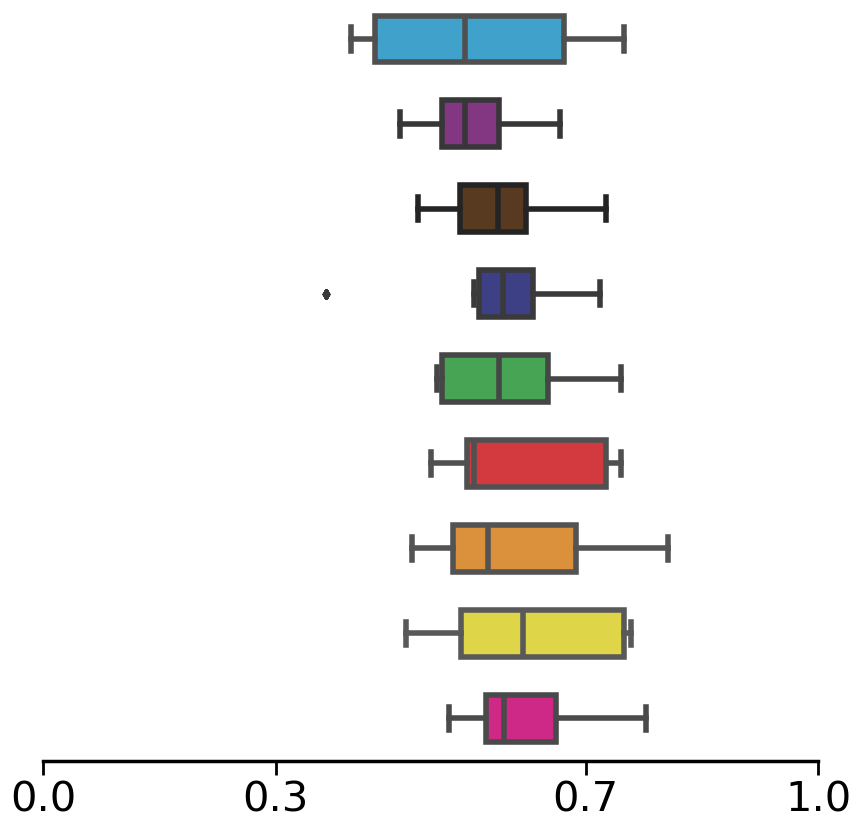

In [354]:

from matplotlib.gridspec import GridSpec

COLORS = ["#FF5A5F", "#FFB400", "#007A87"]


    
# Set up figure and grid
fig = plt.figure(figsize=(10, 10))  # Wider figure to accommodate 9 subplots
gs = GridSpec(10, 1, figure=fig, height_ratios=[2,2,2,2,2,2,2,2,2,.2], hspace=.5)  # 1 row, 9 columns

# Mapping letters to indices for consistent order
order = "OYWNLAIKP"
dd = {order[i]: i for i in range(len(order))}
test_df["numbers"] = test_df["StartAt"].apply(lambda x: dd[x])

# Plotting one subplot per EndAt node
colors = ["#29abe2", "#90298d", "#603a17", "#313590", "#38b34a", "#eb2127", "#f69320", "#f8eb30", "#e90e8b"]
for i, node in enumerate(order):
    ax = fig.add_subplot(gs[i])
    df_from_this_start = test_df[test_df["StartAt"] == node]
    
    # sns.kdeplot(
    #     df_from_this_start["path_mean_acc"].astype(float),
    #     ax=ax,
    #     linewidth=4,
    #     fill=True,
    #     bw_adjust=2,
    #     color=colors[i]
    # )
    sns.boxplot(df_from_this_start["path_mean_acc"], orient='h', color=colors[i], linewidth=4)

    ax.set_xlim(0, 1)  # assuming accuracy is between 0 and 1

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_visible(False)
    ax.spines["bottom"].set_visible(False)
    ax.yaxis.set_visible(False)
    ax.xaxis.set_visible(False)
    
    ax.patch.set_visible(False)
    ax.set_facecolor('none') 

# ax = fig.add_subplot(gs[i])

ax.xaxis.set_visible(True)
ax.yaxis.set_visible(False)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)

ax.spines["bottom"].set_visible(True)
ax.spines["bottom"].set_linewidth(2.5)
ax.spines['bottom'].set_position(('outward', 10))

ax.tick_params(axis='both', which='major', labelsize=30, width=2, length=10)
plt.xticks([0, .3, .7, 1])
plt.xlabel("")


# plt.tight_layout()
plt.show()

# ax.spines["top"].set_visible(False)
# ax.spines["right"].set_visible(False)
# ax.spines["left"].set_visible(False)
# ax.spines["bottom"].set_linewidth(2.5)
# ax.yaxis.set_visible(False)

# ax.tick_params(axis='both', which='major', labelsize=30, width=2, length=10)
# plt.xticks([]])
# plt.xlabel(x_label, fontsize=30)


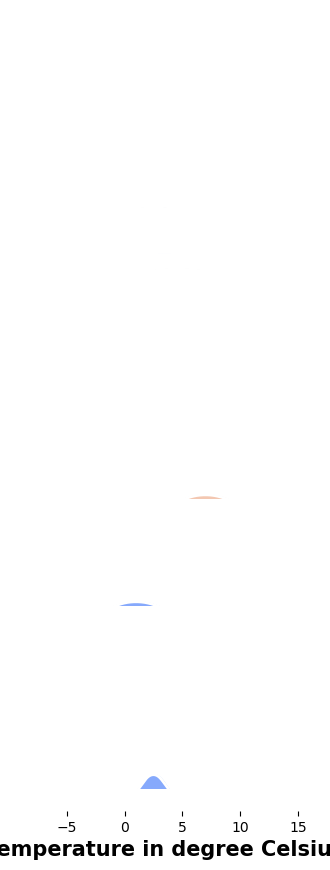

In [355]:
pd.DataFrame.iteritems = pd.DataFrame.items

test_df["numbers"] = test_df["EndAt"].apply(lambda x: dd[x])

end_node_means = test_df.groupby(["StartAt", "EndAt"])['accuracy'].mean()
end_node_numbers = test_df.groupby(["StartAt", "EndAt"])['numbers'].mean()

ddf = pd.DataFrame({"numbers": end_node_means, "means": end_node_numbers})

# we generate a color palette with Seaborn.color_palette()
pal = sns.color_palette(palette='coolwarm', n_colors=12)

# in the sns.FacetGrid class, the 'hue' argument is the one that is the one that will be represented by colors with 'palette'
g = sns.FacetGrid(ddf, row='numbers', hue='numbers', aspect=20, height=0.2, palette=pal)

# then we add the densities kdeplots for each month
g.map(sns.kdeplot, 'means',
      bw_adjust=1, clip_on=False,
      fill=True, alpha=1, linewidth=1.5)

# here we add a white line that represents the contour of each kdeplot
g.map(sns.kdeplot, 'means', 
      bw_adjust=1, clip_on=False, 
      color="w", lw=2)

# # here we add a horizontal line for each plot
# g.map(plt.axhline, y=0,
#       lw=2, clip_on=False)

# we loop over the FacetGrid figure axes (g.axes.flat) and add the month as text with the right color
# notice how ax.lines[-1].get_color() enables you to access the last line's color in each matplotlib.Axes
# for i, ax in enumerate(g.axes.flat):
#     ax.text(-15, 0.02, month_dict[i+1],
#             fontweight='bold', fontsize=15,
#             color=ax.lines[-1].get_color())
    
# we use matplotlib.Figure.subplots_adjust() function to get the subplots to overlap
g.fig.subplots_adjust(hspace=-0.3)

# eventually we remove axes titles, yticks and spines
g.set_titles("")
g.set(yticks=[])
g.despine(bottom=True, left=True, right=True)

plt.setp(ax.get_xticklabels(), fontsize=15, fontweight='bold')
plt.xlabel('Temperature in degree Celsius', fontweight='bold', fontsize=15)

plt.show()

[[<Axes: title={'center': 'numbers = 0.0'}>]
 [<Axes: title={'center': 'numbers = 1.0'}>]
 [<Axes: title={'center': 'numbers = 2.0'}>]
 [<Axes: title={'center': 'numbers = 3.0'}>]
 [<Axes: title={'center': 'numbers = 4.0'}>]
 [<Axes: title={'center': 'numbers = 5.0'}>]
 [<Axes: title={'center': 'numbers = 6.0'}>]
 [<Axes: title={'center': 'numbers = 7.0'}>]
 [<Axes: title={'center': 'numbers = 8.0'}, xlabel='means'>]]


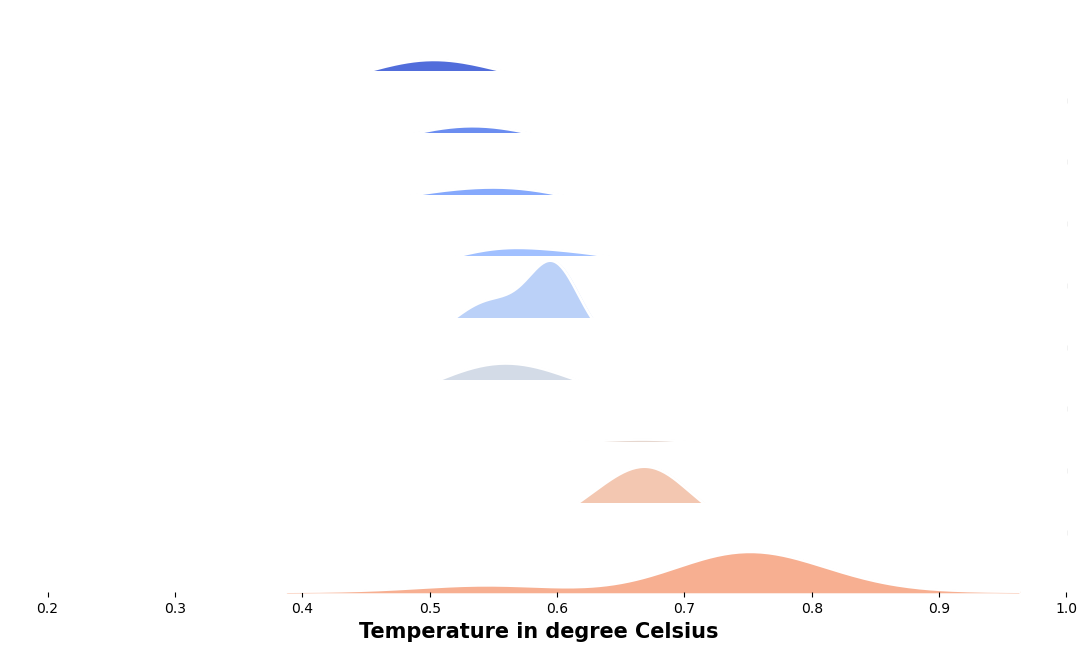

In [356]:
ddf = pd.DataFrame({"numbers": start_node_numbers, "means": start_node_means})

# we generate a color palette with Seaborn.color_palette()
pal = sns.color_palette(palette='coolwarm', n_colors=12)

# in the sns.FacetGrid class, the 'hue' argument is the one that is the one that will be represented by colors with 'palette'
g = sns.FacetGrid(ddf, row='numbers', hue='numbers', aspect=15, height=0.75, palette=pal)

# then we add the densities kdeplots for each month
g.map(sns.kdeplot, 'means',
      bw_adjust=1, clip_on=False,
      fill=True, alpha=1, linewidth=1.5)

# here we add a white line that represents the contour of each kdeplot
g.map(sns.kdeplot, 'means', 
      bw_adjust=1, clip_on=False, 
      color="w", lw=2)

# # here we add a horizontal line for each plot
# g.map(plt.axhline, y=0,
#       lw=2, clip_on=False)

# we loop over the FacetGrid figure axes (g.axes.flat) and add the month as text with the right color
# notice how ax.lines[-1].get_color() enables you to access the last line's color in each matplotlib.Axes
# for i, ax in enumerate(g.axes.flat):
#     ax.text(-15, 0.02, month_dict[i+1],
#             fontweight='bold', fontsize=15,
#             color=ax.lines[-1].get_color())
    
# we use matplotlib.Figure.subplots_adjust() function to get the subplots to overlap
g.fig.subplots_adjust(hspace=-0.3)

print(g.axes)

# eventually we remove axes titles, yticks and spines
g.set_titles("")
g.set(yticks=[])
g.despine(bottom=True, left=True, right=True)

plt.setp(ax.get_xticklabels(), fontsize=15, fontweight='bold')
plt.xlabel('Temperature in degree Celsius', fontweight='bold', fontsize=15)

plt.show()

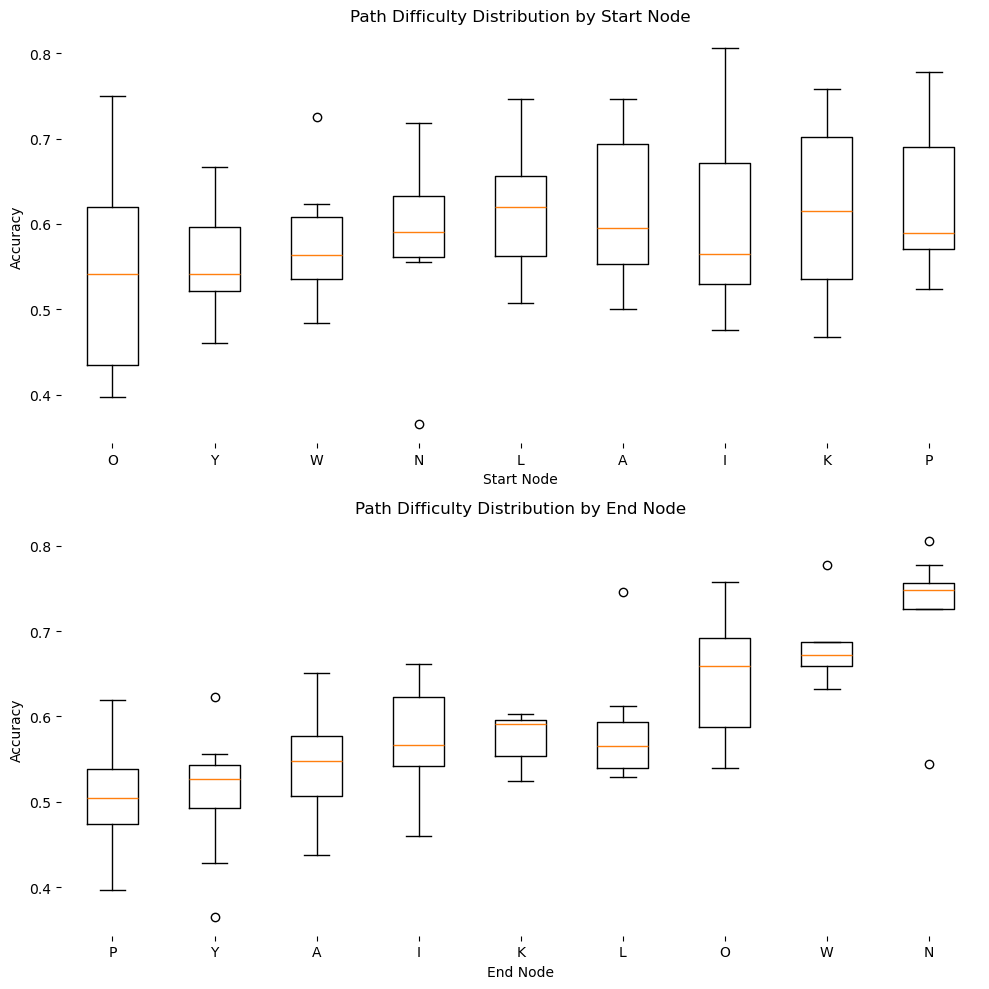

In [357]:
# Create visualization of accuracies by start and end nodes
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 10))

# Calculate mean accuracy per start node to determine order
start_node_means = test_df.groupby('StartAt')['accuracy'].mean()
node_order = start_node_means.sort_values(ascending=True).index

# 1. Box plots of path accuracies grouped by start node
path_data = []
for i in node_order:
    node_data = test_df[test_df['StartAt'] == i].groupby("StartEnd")["accuracy"].apply(np.mean)
    path_data.append(node_data.values)

bp = ax1.boxplot(path_data)

ax1.set_xlabel('Start Node')
ax1.set_ylabel('Accuracy')
ax1.set_title('Path Difficulty Distribution by Start Node')
ax1.set_xticks(range(1, len(node_order) + 1), list(node_order))
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.spines['left'].set_visible(False)
ax1.spines['bottom'].set_visible(False)

# Calculate mean accuracy per end node to determine order
end_node_means = test_df.groupby('EndAt')['accuracy'].mean()
node_order = end_node_means.sort_values(ascending=True).index

# 2. Box plots of path accuracies grouped by end node
path_data = []
for i in node_order:
    node_data = test_df[test_df['EndAt'] == i].groupby("StartEnd")["accuracy"].apply(np.mean)
    path_data.append(node_data.values)

bp = ax2.boxplot(path_data)

ax2.set_xlabel('End Node')
ax2.set_ylabel('Accuracy')
ax2.set_title('Path Difficulty Distribution by End Node')
ax2.set_xticks(range(1, len(node_order) + 1), list(node_order))
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
ax2.spines['left'].set_visible(False)
ax2.spines['bottom'].set_visible(False)

plt.tight_layout()
plt.show()

### Statistics

In [358]:
# One-way ANOVA for start nodes
start_groups = [group["accuracy"].values for name, group in test_df.groupby("StartAt")]
f_stat_start, p_val_start = stats.f_oneway(*start_groups)

print("One-way ANOVA results for Start Nodes:")
print(f"F-statistic: {f_stat_start:.4f}")
print(f"p-value: {p_val_start:.8f}")

# ANOVA for end nodes  
end_groups = [group["accuracy"].values for name, group in test_df.groupby("EndAt")]
f_stat_end, p_val_end = stats.f_oneway(*end_groups)

print("\nOne-way ANOVA results for End Nodes:")
print(f"F-statistic: {f_stat_end:.4f}") 
print(f"p-value: {p_val_end:.8f}")

One-way ANOVA results for Start Nodes:
F-statistic: 2.0841
p-value: 0.03392149

One-way ANOVA results for End Nodes:
F-statistic: 13.1234
p-value: 0.00000000


In [359]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd

# For start nodes
print("\nSignificant pairwise comparisons for Start Nodes:")
# Prepare data for Tukey's test
start_data = test_df[['StartAt', 'accuracy']].copy()
# Perform Tukey's test
tukey_start = pairwise_tukeyhsd(start_data['accuracy'], start_data['StartAt'])
# Print only significant differences
summary = tukey_start.summary()
print(summary)
significant_rows = [i for i, reject in enumerate(tukey_start.reject) if reject]
for row in significant_rows:
    print(summary[row])

# For end nodes  
print("\nSignificant pairwise comparisons for End Nodes:")
# Prepare data for Tukey's test
end_data = test_df[['EndAt', 'accuracy']].copy()
# Perform Tukey's test
tukey_end = pairwise_tukeyhsd(end_data['accuracy'], end_data['EndAt'])
# Print only significant differences
summary = tukey_end.summary()
print(summary)
significant_rows = [i for i, reject in enumerate(tukey_end.reject) if reject]
for row in significant_rows:
    print(summary[row])

# Using pairwise t-tests with Bonferroni correction
from itertools import combinations

def perform_pairwise_tests(df, node_column):
    nodes = df[node_column].unique()
    results = []
    for n1, n2 in combinations(nodes, 2):
        group1 = df[df[node_column] == n1]['accuracy']
        group2 = df[df[node_column] == n2]['accuracy']
        t_stat, p_val = ttest_ind(group1, group2)
        results.append({
            'Node1': n1,
            'Node2': n2,
            't_statistic': t_stat,
            'p_value': p_val
        })
    return pd.DataFrame(results)
    

# # Get significant pairwise comparisons for start nodes
# print("\nSignificant pairwise t-tests for Start Nodes (with Bonferroni correction):")
# start_comparisons = perform_pairwise_tests(test_df, 'EndAt')
# # Apply Bonferroni correction
# n_comparisons = len(start_comparisons)
# print(n_comparisons)
# start_comparisons['adjusted_p'] = start_comparisons['p_value'] * n_comparisons
# print(start_comparisons['p_value'])
# start_comparisons['bh_adjusted_p'] = stats.false_discovery_control(start_comparisons['p_value'], method="bh")

# # Print only significant differences (p < 0.05)
# print(start_comparisons[start_comparisons['bh_adjusted_p'] < 0.05])


Significant pairwise comparisons for Start Nodes:
Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj   lower  upper  reject
---------------------------------------------------
     A      I    0.002    1.0 -0.0926 0.0966  False
     A      K   0.0034    1.0 -0.0915 0.0983  False
     A      L  -0.0052    1.0 -0.0999 0.0895  False
     A      N  -0.0357 0.9628 -0.1305 0.0591  False
     A      O  -0.0718 0.3105 -0.1664 0.0229  False
     A      P   0.0135    1.0 -0.0811 0.1082  False
     A      W  -0.0387  0.942 -0.1338 0.0564  False
     A      Y  -0.0611 0.5421 -0.1558 0.0336  False
     I      K   0.0014    1.0 -0.0931 0.0959  False
     I      L  -0.0072    1.0 -0.1016 0.0871  False
     I      N  -0.0378 0.9475 -0.1322 0.0567  False
     I      O  -0.0738 0.2683 -0.1681 0.0205  False
     I      P   0.0115    1.0 -0.0827 0.1058  False
     I      W  -0.0407 0.9213 -0.1354  0.054  False
     I      Y  -0.0631 0.4898 -0.1575 0.0312  False
     K      L

## 7. Heatmaps and foils (Fig. 3E)

In [360]:
# Create heatmap of accuracies
acc_matrix = np.zeros((len(OBJECTS), len(OBJECTS)))

# First calculate accuracies and end node averages
end_node_avgs = {}
for end in OBJECTS:
    end_accs = []
    for start in OBJECTS:
        if start != end:
            acc = np.mean(test_df[(test_df["StartAt"]==start) & 
                                (test_df["EndAt"]==end)]["accuracy"])
            end_accs.append(acc)
    end_node_avgs[end] = np.mean(end_accs)

# Sort OBJECTS by end node average accuracy
sorted_objects = sorted(OBJECTS, key=lambda x: end_node_avgs[x], reverse=True)

# Create matrix with sorted indices
for i, start in enumerate(sorted_objects):
    for j, end in enumerate(sorted_objects):
        if start != end:
            acc = np.mean(test_df[(test_df["StartAt"]==start) & 
                                (test_df["EndAt"]==end)]["accuracy"])
            acc_matrix[i,j] = acc
        else:
            acc_matrix[i,j] = np.nan  # Set diagonal to NaN instead of 0

fig = go.Figure(data=go.Heatmap(
    z=acc_matrix,
    x=list(sorted_objects),
    y=list(sorted_objects),
    colorscale='RdBu',
    text=np.round(acc_matrix, 3),
    texttemplate='%{text}',
    textfont={"size": 10},
    colorbar=dict(title='Accuracy'),
    zmin=np.nanmin(acc_matrix),  # Ignore NaN values when setting scale
    zmax=np.nanmax(acc_matrix)
))

fig.update_layout(
    title='Path Accuracies by Start and End Nodes',
    xaxis_title='End Node',
    yaxis_title='Start Node',
    width=600,
    height=600,
)

fig.show()

Winners w/ other object: total=62 mean=0.02
Losers w/ other object not end: total=246 mean=0.13
Losers end other object: total=1183 mean=0.63


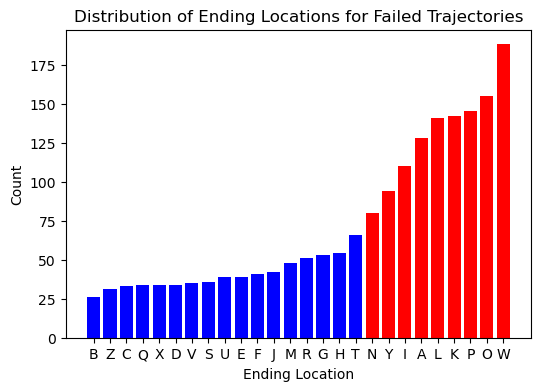

In [361]:
#### Looking for common foilsOBJECTS = "AIKLNOPWY"

def contains_other_obj(traj, start, end):
    for obj in OBJECTS:
        if obj != start and obj != end:
            if obj in traj:
                return True
    return False

winner_objects = []
loser_objects = []
loser_end_object = []
loser_ends = {}
for (start_node, end_node), group in test_df.groupby(["StartAt", "EndAt"]):
    trajs = generate_trajs_from_df(group)
    accs = np.array(group["accuracy"])
    
    for traj, acc in zip(trajs, accs):
        if acc:
            winner_objects.append(contains_other_obj(traj[:-2], start_node, end_node))
        else:
            loser_objects.append(contains_other_obj(traj[:-2], start_node, end_node)) # sometimes it is double end bc button?
            
            end_node = traj[-1][-1]
            loser_end_object.append(end_node in OBJECTS)

            loser_ends[end_node] = loser_ends.get(end_node, 0) + 1


    
print(f"Winners w/ other object: total={np.sum(winner_objects)} mean={np.mean(winner_objects):.2f}")
print(f"Losers w/ other object not end: total={np.sum(loser_objects)} mean={np.mean(loser_objects):.2f}")
print(f"Losers end other object: total={np.sum(loser_end_object)} mean={np.mean(loser_end_object):.2f}")

plt.figure(figsize=(6, 4))

# Sort the data by count
sorted_items = sorted(loser_ends.items(), key=lambda x: x[1])
locations, counts = zip(*sorted_items)

# Create color list - objects in red, other locations in blue
colors = ["red" if loc in OBJECTS else "blue" for loc in locations]

plt.bar(locations, counts, color=colors)
plt.title("Distribution of Ending Locations for Failed Trajectories")
plt.xlabel("Ending Location")
plt.ylabel("Count")
plt.show()



Most common failure modes:
--------------------------------------------------
Target: A            | Most common failure: L            | Count:   36 | Pct: 0.15
Target: I            | Most common failure: K            | Count:   28 | Pct: 0.13
Target: K            | Most common failure: O            | Count:   32 | Pct: 0.15
Target: L            | Most common failure: A            | Count:   30 | Pct: 0.15
Target: N            | Most common failure: F            | Count:   17 | Pct: 0.12
Target: O            | Most common failure: K            | Count:   37 | Pct: 0.20
Target: P            | Most common failure: Y            | Count:   36 | Pct: 0.14
Target: W            | Most common failure: P            | Count:   25 | Pct: 0.15
Target: Y            | Most common failure: W            | Count:   33 | Pct: 0.13
--------------------------------------------------


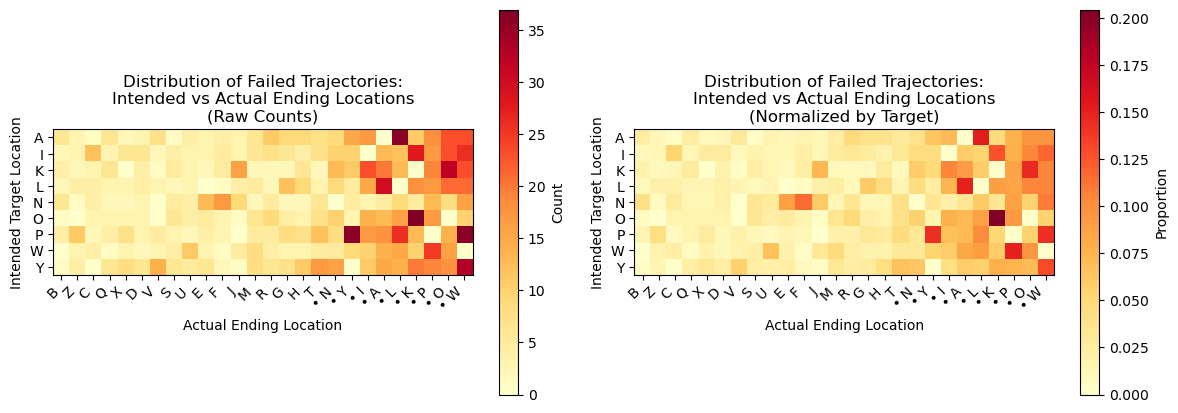

In [362]:
# Create a 2D grid of actual vs intended end locations
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 8))

# Get unique end locations - objects only for y-axis (intended targets)
target_locations = sorted(set(OBJECTS))

# Sort actual locations by frequency like in bar plot
actual_locations = [loc for loc, _ in sorted(loser_ends.items(), key=lambda x: x[1])]
# Add any missing locations from test_df that weren't in loser_ends
remaining_locs = set(test_df['EndAt'].unique()) - set(actual_locations)
actual_locations.extend(sorted(remaining_locs))

# Create a matrix of counts
counts_matrix = np.zeros((len(target_locations), len(actual_locations)))

# Fill the matrix
for (_, end_node), group in test_df.groupby(["StartAt", "EndAt"]):
    trajs = generate_trajs_from_df(group)
    for traj in trajs:
        actual_end = traj[-1][-1]
        if actual_end != end_node:  # Only count failures
            i = target_locations.index(end_node)
            j = actual_locations.index(actual_end)
            counts_matrix[i, j] += 1

# Create normalized matrix
norm_matrix = counts_matrix / counts_matrix.sum(axis=1, keepdims=True)

# Print max failure count for each intended target
print("\nMost common failure modes:")
print("-" * 50)
for i, target in enumerate(target_locations):
    max_count = counts_matrix[i].max()
    max_idx = counts_matrix[i].argmax()
    actual = actual_locations[max_idx]
    max_norm = norm_matrix[i][max_idx]
    print(f"Target: {target:12} | Most common failure: {actual:12} | Count: {int(max_count):4} | Pct: {max_norm:.2f}")
print("-" * 50)


# Create heatmaps
for ax, matrix, title_suffix, label in [
    (ax1, counts_matrix, 'Raw Counts', 'Count'),
    (ax2, norm_matrix, 'Normalized by Target', 'Proportion')
]:
    im = ax.imshow(matrix, cmap='YlOrRd')
    plt.colorbar(im, ax=ax, label=label, shrink=0.5)
    
    # Set labels with different colors for objects vs other locations
    x_labels = [f'\u2022 {loc}' if loc in OBJECTS else loc for loc in actual_locations]
    ax.set_xticks(range(len(actual_locations)))
    ax.set_xticklabels(x_labels, rotation=45, ha='right')
    ax.set_yticks(range(len(target_locations)))
    ax.set_yticklabels(target_locations)
    
    ax.set_xlabel('Actual Ending Location')
    ax.set_ylabel('Intended Target Location')
    ax.set_title(f'Distribution of Failed Trajectories:\nIntended vs Actual Ending Locations\n({title_suffix})')

# Adjust layout to prevent label cutoff
plt.tight_layout()
plt.show()



Most common failure modes (objects only):
--------------------------------------------------
Target: N            | Most common failure: W            | Count:   16 | Pct: 0.25
Target: Y            | Most common failure: W            | Count:   33 | Pct: 0.23
Target: I            | Most common failure: K            | Count:   28 | Pct: 0.20
Target: A            | Most common failure: L            | Count:   36 | Pct: 0.24
Target: L            | Most common failure: A            | Count:   30 | Pct: 0.22
Target: K            | Most common failure: O            | Count:   32 | Pct: 0.21
Target: P            | Most common failure: Y            | Count:   36 | Pct: 0.21
Target: O            | Most common failure: K            | Count:   37 | Pct: 0.31
Target: W            | Most common failure: P            | Count:   25 | Pct: 0.24
--------------------------------------------------


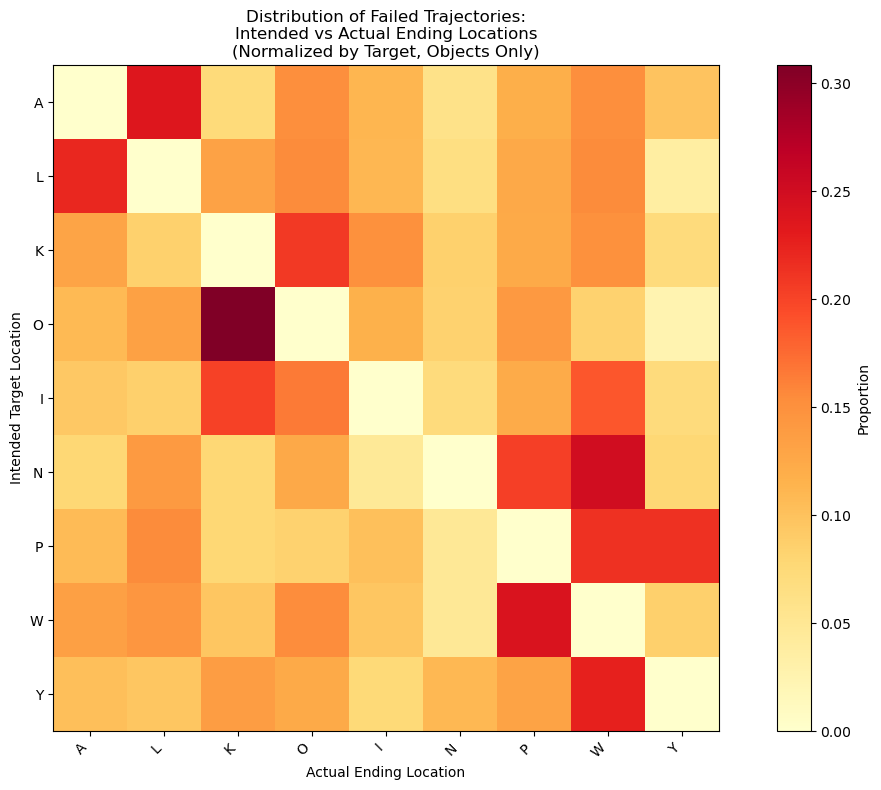

In [363]:
# Create a figure with just normalized heatmap
fig, ax = plt.subplots(figsize=(12, 8))

# Get unique end locations - objects only for y-axis (intended targets)
# OBJECTS = "OYNPALWKI"

# Sort actual locations by frequency like in bar plot
actual_locations = [loc for loc, _ in sorted(loser_ends.items(), key=lambda x: x[1])]
# Add any missing locations from test_df that weren't in loser_ends
remaining_locs = set(test_df['EndAt'].unique()) - set(actual_locations)
actual_locations.extend(sorted(remaining_locs))
# Filter to only show objects
actual_locations = [loc for loc in actual_locations if loc in OBJECTS]

# Use same order for target locations
target_locations = actual_locations.copy()

# Create a matrix of counts
counts_matrix = np.zeros((len(target_locations), len(actual_locations)))

# Fill the matrix
for (_, end_node), group in test_df.groupby(["StartAt", "EndAt"]):
    trajs = generate_trajs_from_df(group)
    for traj in trajs:
        actual_end = traj[-1][-1]
        if actual_end != end_node and actual_end in OBJECTS:  # Only count failures to objects
            i = target_locations.index(end_node)
            j = actual_locations.index(actual_end)
            counts_matrix[i, j] += 1

# Create normalized matrix
norm_matrix = counts_matrix / counts_matrix.sum(axis=1, keepdims=True)

# Print max failure count for each intended target
print("\nMost common failure modes (objects only):")
print("-" * 50)
for i, target in enumerate(target_locations):
    max_count = counts_matrix[i].max()
    max_idx = counts_matrix[i].argmax()
    actual = actual_locations[max_idx]
    max_norm = norm_matrix[i][max_idx]
    print(f"Target: {target:12} | Most common failure: {actual:12} | Count: {int(max_count):4} | Pct: {max_norm:.2f}")
print("-" * 50)

# Define desired order
desired_order = list("ALKOINPWY")

# Reorder matrices according to desired order
order_idx_actual = [actual_locations.index(loc) for loc in desired_order if loc in actual_locations]
order_idx_target = [target_locations.index(loc) for loc in desired_order if loc in target_locations]

norm_matrix = norm_matrix[order_idx_target][:, order_idx_actual]
actual_locations = [actual_locations[i] for i in order_idx_actual]
target_locations = [target_locations[i] for i in order_idx_target]

# Create heatmap
im = ax.imshow(norm_matrix, cmap='YlOrRd')
plt.colorbar(im, ax=ax, label='Proportion', shrink=1)

# Set labels
ax.set_xticks(range(len(actual_locations)))
ax.set_xticklabels(actual_locations, rotation=45, ha='right')
ax.set_yticks(range(len(target_locations)))
ax.set_yticklabels(target_locations)

ax.set_xlabel('Actual Ending Location')
ax.set_ylabel('Intended Target Location')
ax.set_title('Distribution of Failed Trajectories:\nIntended vs Actual Ending Locations\n(Normalized by Target, Objects Only)')

# Adjust layout to prevent label cutoff
plt.tight_layout()
plt.show()


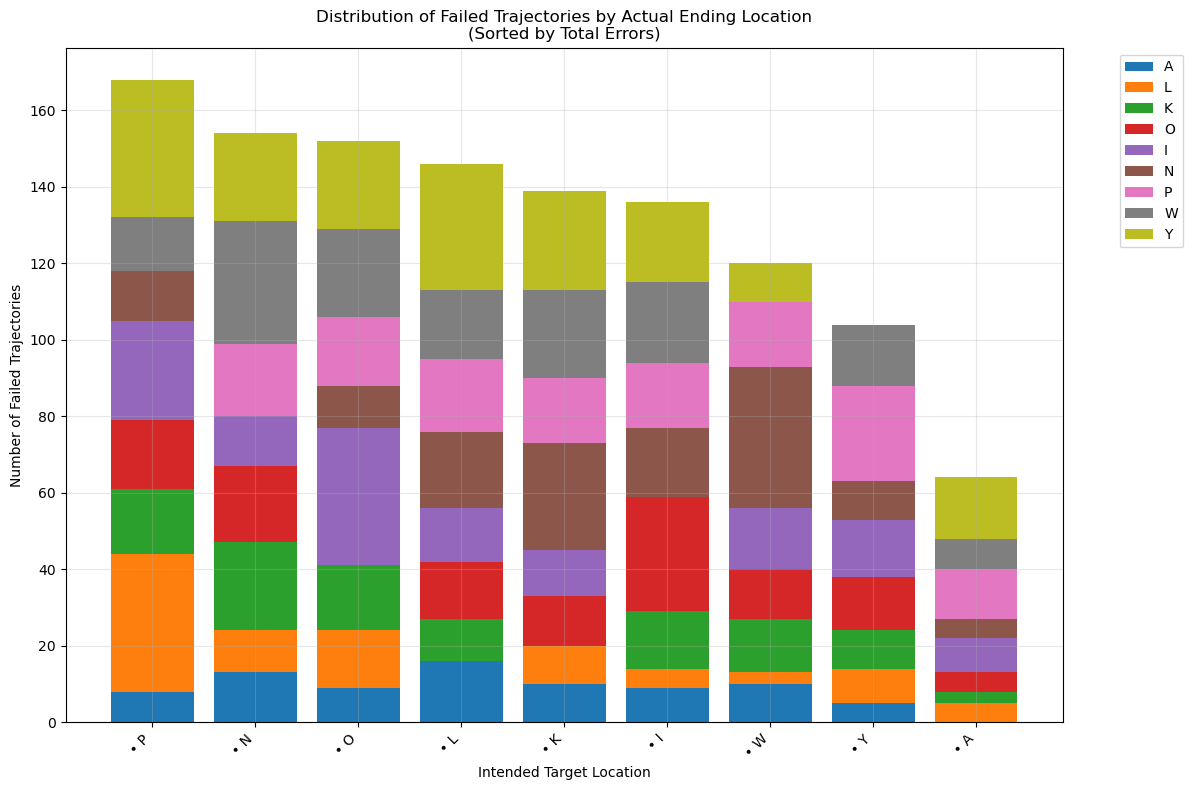

In [364]:
only_use_objects = True

# Create a figure
plt.figure(figsize=(12, 8))

# Calculate total errors for each target location
total_errors = counts_matrix.sum(axis=1)
sorted_indices = np.argsort(total_errors)[::-1]  # Sort in descending order

# Create stacked bar plot
bottom = np.zeros(len(target_locations))
for i, actual in enumerate(actual_locations):
    if (not only_use_objects) or (actual in OBJECTS):
        # Use sorted_indices to index into counts_matrix correctly
        values = counts_matrix.T[i][sorted_indices]  # Transpose to get actual location values
        plt.bar(range(len(target_locations)), values,
               bottom=bottom, label=actual)
        bottom += values

# Set x-axis labels with dots for objects, using sorted order
x_labels = [f'\u2022 {target_locations[i]}' if target_locations[i] in OBJECTS else target_locations[i] 
           for i in sorted_indices]
plt.xticks(range(len(target_locations)), x_labels, rotation=45, ha='right')

plt.xlabel('Intended Target Location')
plt.ylabel('Number of Failed Trajectories')
plt.title('Distribution of Failed Trajectories by Actual Ending Location\n(Sorted by Total Errors)')

# Add legend
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

# Adjust layout to prevent label cutoff
plt.tight_layout()
plt.grid(True, alpha=0.3)
plt.show()


## 8. Miscellaneous Archive

Interactive test path figure, by StartEnd

## Plotting function

In [365]:
# Function to create traces for the bars and the dotted line for average accuracy
def create_trace(data, color_column, group_column, name):
    traces = []
    tickvals = []
    ticktext = []
    
    for group in data[group_column].unique():
        group_data = data[data[group_column] == group]
        # Bar trace
        bar_trace = go.Bar(
            x=group_data["StartEnd"],
            y=group_data["accuracy"],
            marker=dict(color=group_data[color_column]),
            opacity=0.7,
            # name=f"{name}: {group}",
            hovertemplate=(
                f"<br>" +
                "%{customdata}, %{y:.2f}<extra></extra>"
            ),
            customdata=group_data["StartEnd"],
            showlegend=False
        )
        traces.append(bar_trace)
        
        # Dotted line for average accuracy
        avg_accuracy = group_data["accuracy"].mean()
        line_trace = go.Scatter(
            x=group_data["StartEnd"],
            y=[avg_accuracy] * len(group_data),
            mode='lines',
            line=dict(dash='dot', color=group_data[color_column].iloc[0], width=2),
            name=f"Avg {name}: {group}, {avg_accuracy}",
            hovertemplate=(
                f"<b>{name}: {group}</b><br>" +
                "Avg Accuracy: %{y:.2f}<extra></extra>"
            ),
            showlegend=False
        )
        traces.append(line_trace)

        # Custom tick text for the x-axis, center the tick text
        mid_index = len(group_data) // 2
        tickvals.append(group_data["StartEnd"].iloc[mid_index])
        ticktext.append(group)
    
    return traces, tickvals, ticktext

## Do the plotting

In [366]:
# Assuming test_df is your initial DataFrame
new_df = test_df.groupby(["StartAt", "EndAt"])["accuracy"].mean().reset_index()
new_df["StartEnd"] = new_df["StartAt"] + "_" + new_df["EndAt"]

# Calculate min turns; first set turns very high for the wrong people
# Note: there's definitely a smarter way to do this in pandas
test_df["accuracy"] = test_df["accuracy"].astype(bool)
test_df["fake_turns"] = test_df["turns_count"]
test_df.loc[~test_df["accuracy"], "fake_turns"] = 999

test_df["min_turns"] = test_df.groupby("StartEnd")["fake_turns"].transform("min")

# Calculate min path dist; first set v high for the wrong people
# Note: there's definitely a smarter way to do this in pandas
test_df["fake_dist"] = test_df["trajs"].apply(len)
test_df.loc[~test_df["accuracy"], "fake_dist"] = 999

test_df["min_dist"] = test_df.groupby("StartEnd")["fake_dist"].transform("min")

print(new_df)
color_dict = {k: f'rgb({v[0]*255},{v[1]*255},{v[2]*255})' for k, v in zip(new_df["StartAt"].unique(), plt.get_cmap('tab20').colors)}

# # Create the layout for subplots
fig = make_subplots(rows=3, cols=1, vertical_spacing=0.1, subplot_titles=("Grouped by StartAt", "Grouped by EndAt", "Sorted with metrics"))

# Sorting by StartAt
avg_startat = new_df.groupby("StartAt")["accuracy"].mean().sort_values()
new_df["StartAt"] = pd.Categorical(new_df["StartAt"], categories=avg_startat.index, ordered=True)
new_df = new_df.sort_values(["StartAt", "accuracy"])
new_df["colors_start"] = new_df["StartAt"].apply(lambda x: color_dict[x])

# Add traces for StartAt groups
traces_start, tickvals_start, ticktext_start = create_trace(new_df, "colors_start", "StartAt", "StartAt")
for trace in traces_start:
    fig.add_trace(trace, row=1, col=1)
  
# Sorting by EndAt
avg_endat = new_df.groupby("EndAt")["accuracy"].mean().sort_values()
new_df["EndAt"] = pd.Categorical(new_df["EndAt"], categories=avg_endat.index, ordered=True)
new_df = new_df.sort_values(["EndAt", "accuracy"])
new_df["colors_end"] = new_df["EndAt"].apply(lambda x: color_dict[x])

# Add traces for EndAt groups
traces_end, tickvals_end, ticktext_end = create_trace(new_df, "colors_end", "EndAt", "EndAt")
for trace in traces_end:
    fig.add_trace(trace, row=2, col=1)

## Add third plot
# Assuming test_df is your initial DataFrame
metrics_to_plot = ["min_dist", "min_turns", "Euc.Distance", "Path.Distance"]
colors = ["red", "blue", "yellow", "orange"]

# Prepare data
path_accs = test_df[["StartEnd", "path_mean_acc"] + metrics_to_plot].drop_duplicates(subset=["StartEnd"], keep="first")
path_accs = path_accs.sort_values("path_mean_acc")

# Bar plot for path mean accuracy
bar_trace = go.Bar(
    x=path_accs["StartEnd"],
    y=path_accs["path_mean_acc"]*45,
    marker=dict(color="rgba(0, 0, 0, 0.1)"),
    name="Path Mean Accuracy",
    xaxis="x3",
    yaxis="y11",
    hovertemplate="StartEnd: %{x}<br>Path Mean Accuracy: %{customdata:.2f}<extra></extra>",
    customdata=path_accs["path_mean_acc"],

)
fig.add_trace(bar_trace, row=3, col=1)

# Scatter plots for metrics
for metric, color in zip(metrics_to_plot, colors):
    scatter_trace = go.Scatter(
        x=path_accs["StartEnd"],
        y=path_accs[metric],
        mode='markers',
        marker=dict(color=color),
        name=metric,
        xaxis="x3",
        yaxis="y12"
        # hovertemplate=f"StartEnd: <br>{metric}: %{y:.2f}<extra></extra>"#%{x}
    )
    fig.add_trace(scatter_trace, row=3, col=1)

# Update layout for color legends and custom ticks
fig.update_layout(
    height=800, width=800,
    showlegend=True,
    legend=dict(
        x=1.05,
        y=-10,
        traceorder='normal'
    ),
    xaxis=dict(
        tickvals=tickvals_start,
        ticktext=ticktext_start,
        tickmode='array'
    ),
    xaxis2=dict(
        tickvals=tickvals_end,
        ticktext=ticktext_end,
        tickmode='array',
    ),
    yaxis11=dict(title="Path Mean Accuracy", anchor="x3"),
    yaxis12=dict(title="Metrics", anchor="x3", overlaying='y7', side='right'),
)

fig.update_layout(hovermode="closest")

fig.show()
plot(fig, filename="figures/grouped_by_start_end.html")

   StartAt EndAt  accuracy StartEnd
0        A     I  0.555556      A_I
1        A     K  0.546875      A_K
2        A     L  0.746269      A_L
3        A     N  0.725806      A_N
4        A     O  0.682540      A_O
..     ...   ...       ...      ...
67       Y     L  0.539683      Y_L
68       Y     N  0.544118      Y_N
69       Y     O  0.588235      Y_O
70       Y     P  0.619048      Y_P
71       Y     W  0.666667      Y_W

[72 rows x 4 columns]


'figures/grouped_by_start_end.html'